# Setup

In [20]:
import glob
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import obonet
import pandas as pd
import yaml
from matplotlib.colors import LinearSegmentedColormap

# notebook lives in notebooks/, everything else is addressed from the repo root
REPO = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()

CONFIG_FILE = os.path.join(REPO, 'config.yml')
DEEPLOC_DIR = os.path.join(REPO, 'data/deeploc/output')
SPECIES_DIR = os.path.join(REPO, 'data/downloads/species')
OBO_FILE = os.path.join(REPO, 'data/downloads/go.obo')
OUT_DIR = os.path.join(REPO, 'data/deeploc/analysis')

STRING_VERSION = 'v12.0'
GO_CC = 'Cellular Component (Gene Ontology)'
COMPARTMENTS = 'Subcellular localization (COMPARTMENTS)'

os.makedirs(OUT_DIR, exist_ok=True)

In [21]:
# --- plotting defaults: recessive axes, thin marks, no chartjunk ---
SURFACE = '#fcfcfb'
INK = '#0b0b0b'
INK_SOFT = '#52514e'
# categorical slots, assigned in fixed order (never cycled)
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']

plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
    'axes.edgecolor': '#d7d6d1', 'axes.linewidth': 0.8, 'axes.grid': True,
    'grid.color': '#e8e7e2', 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False,
    'text.color': INK, 'axes.labelcolor': INK_SOFT, 'xtick.color': INK_SOFT,
    'ytick.color': INK_SOFT, 'axes.titlecolor': INK,
    'font.size': 9, 'axes.titlesize': 11, 'axes.titlelocation': 'left', 'axes.titlepad': 10,
    'legend.frameon': False,
})


def save(fig, name):
    """Write a figure to the analysis output directory."""
    fig.savefig(os.path.join(OUT_DIR, name))

In [22]:
# --- DeepLoc 2.0 classes and the GO cellular-component term each one maps to ---
DEEPLOC_CLASSES = ['Cytoplasm', 'Nucleus', 'Extracellular', 'Cell membrane', 'Mitochondrion',
                   'Plastid', 'Endoplasmic reticulum', 'Lysosome/Vacuole', 'Golgi apparatus',
                   'Peroxisome']

CLASS_GO_ROOTS = {
    'Cytoplasm': ['GO:0005737'],                      # cytoplasm
    'Nucleus': ['GO:0005634'],                        # nucleus
    'Extracellular': ['GO:0005576'],                  # extracellular region
    'Cell membrane': ['GO:0005886'],                  # plasma membrane
    'Mitochondrion': ['GO:0005739'],                  # mitochondrion
    'Plastid': ['GO:0009536'],                        # plastid (incl. apicoplast)
    'Endoplasmic reticulum': ['GO:0005783'],          # endoplasmic reticulum
    'Lysosome/Vacuole': ['GO:0005764', 'GO:0005773'],  # lysosome, vacuole
    'Golgi apparatus': ['GO:0005794'],                # Golgi apparatus
    'Peroxisome': ['GO:0005777'],                     # peroxisome
}

In [23]:
with open(CONFIG_FILE) as f:
    config = yaml.safe_load(f)

species = {}
for group in ('hosts', 'parasites'):
    for taxid, attr in (config.get(group) or {}).items():
        species[int(taxid)] = {'label': attr.get('label', str(taxid)),
                               'group': 'host' if group == 'hosts' else 'parasite'}

taxids = sorted(int(d) for d in os.listdir(DEEPLOC_DIR)
                if d.isdigit() and glob.glob(os.path.join(DEEPLOC_DIR, d, 'results_*.csv')))

species_df = pd.DataFrame([{'taxid': t,
                            'label': species.get(t, {}).get('label', str(t)),
                            'group': species.get(t, {}).get('group', 'unknown')} for t in taxids])
print(f"{len(taxids)} species with DeepLoc results "
      f"({(species_df.group == 'host').sum()} hosts, {(species_df.group == 'parasite').sum()} parasites)")
species_df.head()

43 species with DeepLoc results (3 hosts, 40 parasites)


,taxid,label,group
0,5660,Leishmania braziliensis,parasite
1,5664,Leishmania major,parasite
2,5671,Leishmania infantum,parasite
3,5722,Trichomonas vaginalis,parasite
4,5759,Entamoeba histolytica,parasite


# Read deeploc

In [24]:
def read_deeploc(taxid):
    """Read the most recent DeepLoc results file for a species."""
    files = sorted(glob.glob(os.path.join(DEEPLOC_DIR, str(taxid), 'results_*.csv')))
    data = pd.read_csv(files[-1])
    data['taxid'] = taxid
    return data


deeploc = pd.concat([read_deeploc(t) for t in taxids], ignore_index=True)
deeploc = deeploc.rename(columns={'Protein_ID': 'protein', 'Localizations': 'localizations',
                                  'Signals': 'signals', 'Membrane types': 'membrane_types'})

# DeepLoc reports one or more localizations, pipe-separated and ordered by confidence
deeploc['predicted'] = deeploc['localizations'].fillna('').apply(
    lambda s: [loc for loc in s.split('|') if loc])
deeploc['top_localization'] = deeploc['predicted'].apply(lambda p: p[0] if p else None)
deeploc['n_predicted'] = deeploc['predicted'].apply(len)
# probability DeepLoc assigned to its top class
deeploc['top_probability'] = [row[loc] if isinstance(loc, str) else np.nan
                              for row, loc in zip(deeploc[DEEPLOC_CLASSES].to_dict('records'),
                                                  deeploc['top_localization'])]
deeploc['signal_list'] = deeploc['signals'].fillna('').apply(
    lambda s: [x for x in s.split('|') if x])
deeploc = deeploc.merge(species_df, on='taxid', how='left')

print(f"{len(deeploc):,} predicted proteins over {deeploc.taxid.nunique()} species")
deeploc[['protein', 'label', 'group', 'top_localization', 'n_predicted',
         'top_probability', 'signals', 'membrane_types']].head()

567,146 predicted proteins over 43 species


,protein,label,group,top_localization,n_predicted,top_probability,signals,membrane_types
0,5660.A4H322,Leishmania braziliensis,parasite,Cytoplasm,1,0.6024,Nuclear export signal,Peripheral|Soluble
1,5660.A4H323,Leishmania braziliensis,parasite,Endoplasmic reticulum,1,0.7045,Signal peptide|Transmembrane domain,Transmembrane
2,5660.A4H324,Leishmania braziliensis,parasite,Mitochondrion,1,0.9161,Mitochondrial transit peptide,Peripheral|Soluble
3,5660.A4H325,Leishmania braziliensis,parasite,Cytoplasm,3,0.7509,Mitochondrial transit peptide|Chloroplast tran...,Peripheral|Soluble
4,5660.A4H326,Leishmania braziliensis,parasite,Mitochondrion,1,0.9192,Mitochondrial transit peptide,Peripheral|Soluble


# Probability distribution

count    567146.000
mean          0.666
std           0.143
min           0.117
25%           0.553
50%           0.649
75%           0.769
max           0.999
Name: top_probability, dtype: float64

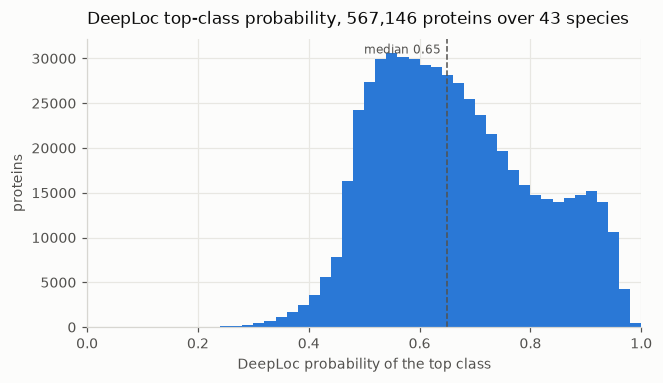

In [25]:
# distribution of the probability DeepLoc assigns to its top-ranked class
probability = deeploc.top_probability.dropna()
bins = np.arange(0, 1.02, 0.02)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.hist(probability, bins=bins, color=SERIES[0])
median = probability.median()
ax.axvline(median, color=INK_SOFT, lw=1, ls='--')
ax.text(median - 0.01, ax.get_ylim()[1] * 0.95, f'median {median:.2f}',
        ha='right', fontsize=8, color=INK_SOFT)
ax.set_xlabel('DeepLoc probability of the top class')
ax.set_ylabel('proteins')
ax.set_xlim(0, 1)
ax.set_title(f'DeepLoc top-class probability, {len(probability):,} proteins over '
             f'{deeploc.taxid.nunique()} species')

probability.describe().round(3)

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
host,63214.0,0.735,0.140,0.276,0.625,0.736,0.860,0.999
parasite,503932.0,0.657,0.141,0.117,0.547,0.639,0.755,0.998


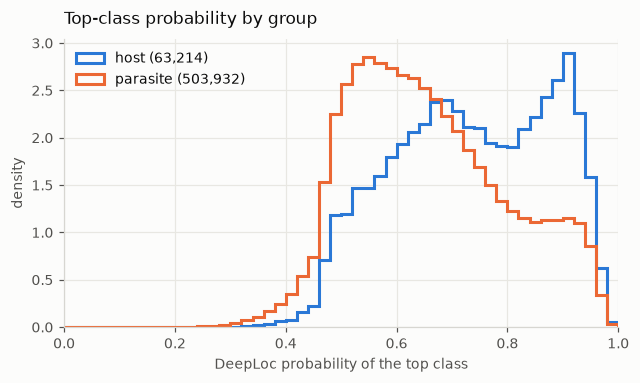

In [26]:
# same distribution, hosts vs parasites, as densities so the two are comparable
fig, ax = plt.subplots(figsize=(6.5, 3.4))
for group, colour in zip(('host', 'parasite'), SERIES):
    part = deeploc.loc[deeploc.group == group, 'top_probability'].dropna()
    ax.hist(part, bins=bins, density=True, histtype='step', lw=2, color=colour,
            label=f'{group} ({len(part):,})')
ax.set_xlabel('DeepLoc probability of the top class')
ax.set_ylabel('density')
ax.set_xlim(0, 1)
ax.set_title('Top-class probability by group')
ax.legend(loc='upper left')

deeploc.groupby('group').top_probability.describe().round(3)

## Human secreted proteins: DeepLoc probability vs COMPARTMENTS score

Restricted to human (9606) proteins whose top-ranked DeepLoc class is **Extracellular**.
For the same proteins, the jensenlab integrated COMPARTMENTS file
(`data/downloads/human_compartment_integrated_full.tsv`) supplies a 0–5 confidence score;
only annotations inside the *extracellular region* subtree (GO:0005576 + descendants) are
comparable with the prediction, and a protein is summarised by its best such score.

The scales differ (probability 0–1, score 0–5), so the two are shown as separate panels.

In [27]:
# Load GO graph
graph = obonet.read_obo(OBO_FILE)
hierarchy = nx.MultiDiGraph((u, v, k) for u, v, k in graph.edges(keys=True)
                            if k in ('is_a', 'part_of')).reverse(copy=False)
# Get extracellular terms
extracellular_terms = {'GO:0005576'} | nx.descendants(hierarchy, 'GO:0005576') # extracellular region plus every descendant reachable through is_a / part_of

print(f'{len(extracellular_terms):,} GO terms in the extracellular region subtree')
print(extracellular_terms)
for go_id in sorted(extracellular_terms)[0:10]:
      print(go_id, graph.nodes[go_id].get('name', '<no name>'))

276 GO terms in the extracellular region subtree
{'GO:0097570', 'GO:0140149', 'GO:0070701', 'GO:0043264', 'GO:0005621', 'GO:0097311', 'GO:0043667', 'GO:0061696', 'GO:0043670', 'GO:0005584', 'GO:0140156', 'GO:0005599', 'GO:0005586', 'GO:0031244', 'GO:0071754', 'GO:0043672', 'GO:0098595', 'GO:0042603', 'GO:0005576', 'GO:0098647', 'GO:0005614', 'GO:0031160', 'GO:0030288', 'GO:0140644', 'GO:1990971', 'GO:0043511', 'GO:0009530', 'GO:0042600', 'GO:1990339', 'GO:0033165', 'GO:0030445', 'GO:0030115', 'GO:0098648', 'GO:0005593', 'GO:0070744', 'GO:0120216', 'GO:0009505', 'GO:0009519', 'GO:1990563', 'GO:0048222', 'GO:0070825', 'GO:0009531', 'GO:0048225', 'GO:0042568', 'GO:0031240', 'GO:0034362', 'GO:0043669', 'GO:1990916', 'GO:0060109', 'GO:0070263', 'GO:0005595', 'GO:0043668', 'GO:0071752', 'GO:1990319', 'GO:0009276', 'GO:0071748', 'GO:0043261', 'GO:0140151', 'GO:0043673', 'GO:0072534', 'GO:0042627', 'GO:0043188', 'GO:0099544', 'GO:1990325', 'GO:0140150', 'GO:1990320', 'GO:0070645', 'GO:0097220'

In [28]:
HUMAN = 9606

In [29]:
# Read compartments data
COMPARTMENTS_FILE = os.path.join(REPO, 'data/downloads/human_compartment_integrated_full.tsv')
# jensenlab integrated file: <id> <name> <GO term> <term name> <source> <evidence> <score>
compartments = pd.read_csv(COMPARTMENTS_FILE, sep='\t', header=None, usecols=[0, 2, 3, 4],
                           names=['id', 'term', 'term_name', 'score'],
                           dtype={'id': str, 'term': str, 'term_name': str, 'score': float})
compartments['protein'] = f'{HUMAN}.' + compartments['id']
compartments.head()

,id,term,term_name,score,protein
0,18S_rRNA,GO:0005840,Ribosome,3.632,9606.18S_rRNA
1,18S_rRNA,GO:0005575,cellular_component,3.525,9606.18S_rRNA
2,18S_rRNA,GO:0110165,Cellular anatomical entity,3.520,9606.18S_rRNA
3,18S_rRNA,GO:0005622,Intracellular anatomical structure,3.513,9606.18S_rRNA
4,18S_rRNA,GO:0043229,Intracellular organelle,3.499,9606.18S_rRNA


In [30]:
# Deeploc predictions for human extracellular
secreted = deeploc[(deeploc.taxid == HUMAN) & (deeploc.top_localization == 'Extracellular')]
print(f'{len(secreted):,} human proteins predicted Extracellular '
      f'({len(secreted) / (deeploc.taxid == HUMAN).sum():.1%} of the human proteins)')
secreted_proteins = set(secreted.protein)
secreted.head()

1,597 human proteins predicted Extracellular (8.1% of the human proteins)


,protein,localizations,signals,membrane_types,Cytoplasm,Nucleus,Extracellular,Cell membrane,Mitochondrion,Plastid,...,Lipid anchor,Soluble,taxid,predicted,top_localization,n_predicted,top_probability,signal_list,label,group
285922,9606.ENSP00000002165,Extracellular,Signal peptide,Soluble,0.2038,0.1477,0.6684,0.2520,0.0528,0.0039,...,0.1192,0.7134,9606,[Extracellular],Extracellular,1,0.6684,[Signal peptide],Homo sapiens,host
285923,9606.ENSP00000002596,Extracellular|Golgi apparatus,Signal peptide|Transmembrane domain,Transmembrane,0.1425,0.1022,0.6801,0.2377,0.1389,0.0059,...,0.0962,0.3152,9606,"[Extracellular, Golgi apparatus]",Extracellular,2,0.6801,"[Signal peptide, Transmembrane domain]",Homo sapiens,host
285924,9606.ENSP00000002829,Extracellular,Signal peptide,Peripheral|Soluble,0.3031,0.1315,0.7735,0.5121,0.1093,0.0018,...,0.2595,0.6113,9606,[Extracellular],Extracellular,1,0.7735,[Signal peptide],Homo sapiens,host
285953,9606.ENSP00000008938,Extracellular,Signal peptide,Soluble,0.1648,0.0618,0.9220,0.2617,0.1239,0.0146,...,0.1726,0.8020,9606,[Extracellular],Extracellular,1,0.9220,[Signal peptide],Homo sapiens,host
285958,9606.ENSP00000011292,Extracellular|Lysosome/Vacuole,Signal peptide,Soluble,0.1547,0.0287,0.9270,0.2483,0.0593,0.0274,...,0.0685,0.8541,9606,"[Extracellular, Lysosome/Vacuole]",Extracellular,2,0.9270,[Signal peptide],Homo sapiens,host


In [31]:
extracellular_annotations = compartments[compartments.protein.isin(secreted_proteins)
                                         & compartments.term.isin(extracellular_terms)] #the COMPARTMENTS rows that are both one of the predicted-secreted proteins, and an extracellular annotation.
# one value per protein: the strongest extracellular evidence COMPARTMENTS has for it
best_score = extracellular_annotations.groupby('protein').score.max()

print(f'{len(extracellular_annotations):,} extracellular annotations for '
      f'{len(best_score):,} of the {len(secreted_proteins):,} predicted-secreted proteins '
      f'({len(best_score) / len(secreted_proteins):.1%} covered)')
extracellular_annotations.head()

45,789 extracellular annotations for 1,574 of the 1,597 predicted-secreted proteins (98.6% covered)


,id,term,term_name,score,protein
25306,ENSP00000002165,GO:0005576,Extracellular region,5.000,9606.ENSP00000002165
25323,ENSP00000002165,GO:0043230,Extracellular organelle,4.232,9606.ENSP00000002165
25324,ENSP00000002165,GO:0065010,Extracellular membrane-bounded organelle,4.230,9606.ENSP00000002165
25325,ENSP00000002165,GO:1903561,Extracellular vesicle,4.230,9606.ENSP00000002165
25326,ENSP00000002165,GO:0070062,Extracellular exosome,4.217,9606.ENSP00000002165


In [32]:
# reference annotations, per source: proteins annotated to each DeepLoc class, and proteins
# mappable to any class. Built from the STRING enrichment cache written by deeploc_analysis.ipynb.
REFERENCE_CACHE = os.path.join(OUT_DIR, 'reference_labels.parquet')
if not os.path.exists(REFERENCE_CACHE):
    raise FileNotFoundError(f'{REFERENCE_CACHE} not found - run section 4 of '
                            'deeploc_analysis.ipynb once to build it')
reference = pd.read_parquet(REFERENCE_CACHE)

class_positives = {}    # source -> {dl_class: set(proteins annotated to it)}
mappable_proteins = {}   # source -> set(proteins mappable to any class)
for source, part in reference.groupby('source'):
    class_positives[source] = {c: set(rows.protein) for c, rows in part.groupby('dl_class')}
    mappable_proteins[source] = set(part.protein)

print({s: f'{len(p):,} mappable proteins' for s, p in mappable_proteins.items()})

{'COMPARTMENTS': '205,695 mappable proteins', 'GO CC': '296,533 mappable proteins'}


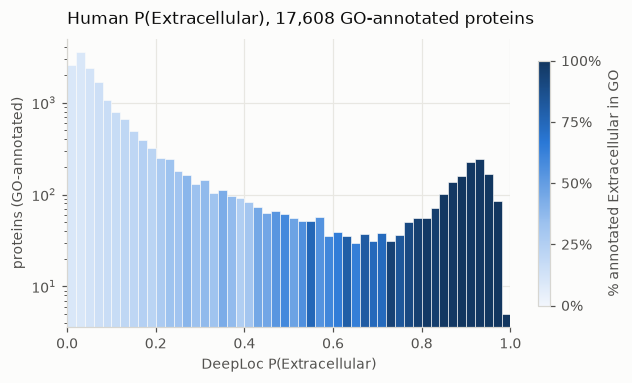

In [33]:
# distribution of the Extracellular probability (not the top class) over all human proteins,
# each bar coloured by the % of proteins in that bin annotated Extracellular in GO
# (GO-mappable proteins only, so bar height and colour share a denominator).
SEQ = LinearSegmentedColormap.from_list('seq_blue', ['#f2f6fc', '#9dc2ef', '#2a78d6', '#12365f'])

go_ec_all = class_positives['GO CC'].get('Extracellular', set())
sub = deeploc[(deeploc.taxid == HUMAN)
              & deeploc.protein.isin(mappable_proteins['GO CC'])].copy()
sub['is_go_ec'] = sub.protein.isin(go_ec_all)

edges = np.arange(0, 1.02, 0.02)
b = np.clip(np.digitize(sub['Extracellular'], edges) - 1, 0, len(edges) - 2)
counts = np.array([(b == i).sum() for i in range(len(edges) - 1)])
frac_ec = np.array([sub.is_go_ec[b == i].mean() if (b == i).any() else np.nan
                    for i in range(len(edges) - 1)])

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(edges[:-1], counts, width=np.diff(edges), align='edge',
       color=SEQ(np.nan_to_num(frac_ec)), edgecolor=SURFACE, linewidth=0.4)
ax.set_xlabel('DeepLoc P(Extracellular)')
ax.set_ylabel('proteins (GO-annotated)')
ax.set_xlim(0, 1)
ax.set_yscale('log')  # most proteins sit near 0, so a log count axis keeps the tail visible
ax.set_title(f'Human P(Extracellular), {len(sub):,} GO-annotated proteins')
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=SEQ), ax=ax, shrink=0.85,
                    label='% annotated Extracellular in GO')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])
save(fig, 'extracellular_prob_hist_by_go_human.png')

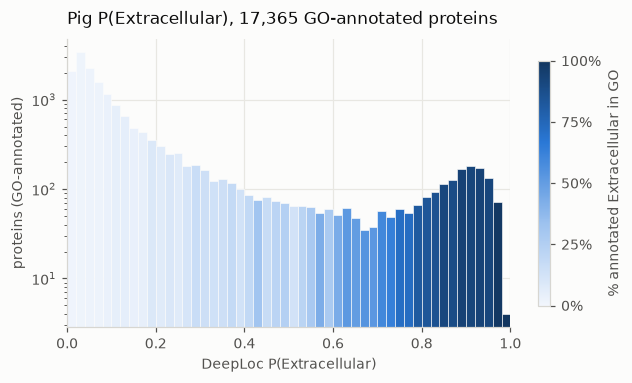

In [34]:
# same plot for pig (Sus scrofa, 9823) - GO CC only, jensenlab has no compartment file for pig
PIG = 9823

go_ec_all = class_positives['GO CC'].get('Extracellular', set())
sub = deeploc[(deeploc.taxid == PIG)
              & deeploc.protein.isin(mappable_proteins['GO CC'])].copy()
sub['is_go_ec'] = sub.protein.isin(go_ec_all)

edges = np.arange(0, 1.02, 0.02)
b = np.clip(np.digitize(sub['Extracellular'], edges) - 1, 0, len(edges) - 2)
counts = np.array([(b == i).sum() for i in range(len(edges) - 1)])
frac_ec = np.array([sub.is_go_ec[b == i].mean() if (b == i).any() else np.nan
                    for i in range(len(edges) - 1)])

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(edges[:-1], counts, width=np.diff(edges), align='edge',
       color=SEQ(np.nan_to_num(frac_ec)), edgecolor=SURFACE, linewidth=0.4)
ax.set_xlabel('DeepLoc P(Extracellular)')
ax.set_ylabel('proteins (GO-annotated)')
ax.set_xlim(0, 1)
ax.set_yscale('log')
ax.set_title(f'Pig P(Extracellular), {len(sub):,} GO-annotated proteins')
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=SEQ), ax=ax, shrink=0.85,
                    label='% annotated Extracellular in GO')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])
save(fig, 'extracellular_prob_hist_by_go_pig.png')

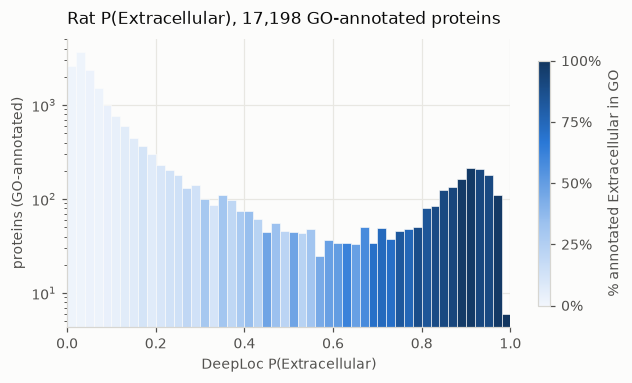

In [35]:
# same plot for rat (Rattus norvegicus, 10116)
RAT = 10116

go_ec_all = class_positives['GO CC'].get('Extracellular', set())
sub = deeploc[(deeploc.taxid == RAT)
              & deeploc.protein.isin(mappable_proteins['GO CC'])].copy()
sub['is_go_ec'] = sub.protein.isin(go_ec_all)

edges = np.arange(0, 1.02, 0.02)
b = np.clip(np.digitize(sub['Extracellular'], edges) - 1, 0, len(edges) - 2)
counts = np.array([(b == i).sum() for i in range(len(edges) - 1)])
frac_ec = np.array([sub.is_go_ec[b == i].mean() if (b == i).any() else np.nan
                    for i in range(len(edges) - 1)])

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(edges[:-1], counts, width=np.diff(edges), align='edge',
       color=SEQ(np.nan_to_num(frac_ec)), edgecolor=SURFACE, linewidth=0.4)
ax.set_xlabel('DeepLoc P(Extracellular)')
ax.set_ylabel('proteins (GO-annotated)')
ax.set_xlim(0, 1)
ax.set_yscale('log')
ax.set_title(f'Rat P(Extracellular), {len(sub):,} GO-annotated proteins')
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=SEQ), ax=ax, shrink=0.85,
                    label='% annotated Extracellular in GO')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])
save(fig, 'extracellular_prob_hist_by_go_rat.png')

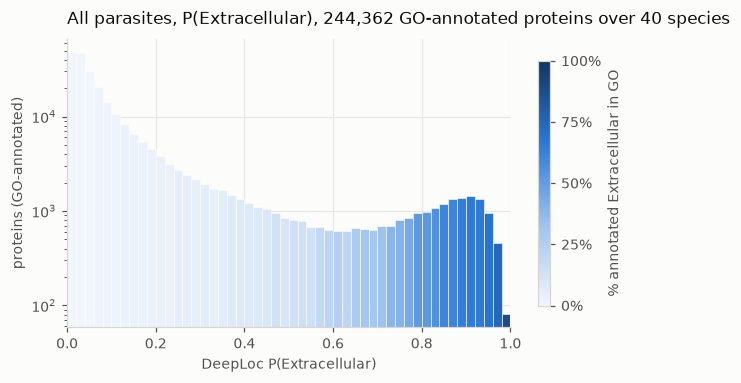

In [36]:
# same plot for all parasite species pooled together
go_ec_all = class_positives['GO CC'].get('Extracellular', set())
sub = deeploc[(deeploc.group == 'parasite')
              & deeploc.protein.isin(mappable_proteins['GO CC'])].copy()
sub['is_go_ec'] = sub.protein.isin(go_ec_all)

edges = np.arange(0, 1.02, 0.02)
b = np.clip(np.digitize(sub['Extracellular'], edges) - 1, 0, len(edges) - 2)
counts = np.array([(b == i).sum() for i in range(len(edges) - 1)])
frac_ec = np.array([sub.is_go_ec[b == i].mean() if (b == i).any() else np.nan
                    for i in range(len(edges) - 1)])

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(edges[:-1], counts, width=np.diff(edges), align='edge',
       color=SEQ(np.nan_to_num(frac_ec)), edgecolor=SURFACE, linewidth=0.4)
ax.set_xlabel('DeepLoc P(Extracellular)')
ax.set_ylabel('proteins (GO-annotated)')
ax.set_xlim(0, 1)
ax.set_yscale('log')
ax.set_title(f'All parasites, P(Extracellular), {len(sub):,} GO-annotated proteins '
             f'over {sub.taxid.nunique()} species')
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=SEQ), ax=ax, shrink=0.85,
                    label='% annotated Extracellular in GO')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])
save(fig, 'extracellular_prob_hist_by_go_parasites.png')

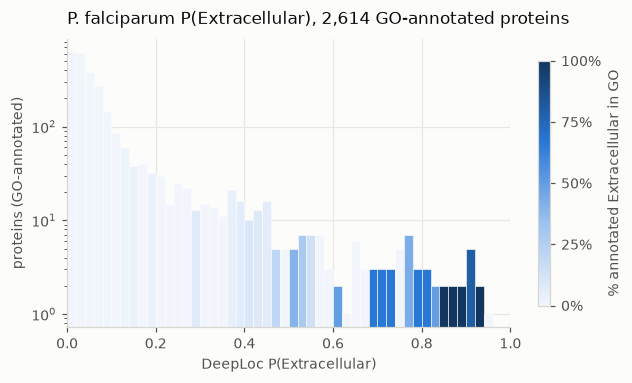

In [37]:
# same plot for Plasmodium falciparum (36329) only
PFALCIPARUM = 36329

go_ec_all = class_positives['GO CC'].get('Extracellular', set())
sub = deeploc[(deeploc.taxid == PFALCIPARUM)
              & deeploc.protein.isin(mappable_proteins['GO CC'])].copy()
sub['is_go_ec'] = sub.protein.isin(go_ec_all)

edges = np.arange(0, 1.02, 0.02)
b = np.clip(np.digitize(sub['Extracellular'], edges) - 1, 0, len(edges) - 2)
counts = np.array([(b == i).sum() for i in range(len(edges) - 1)])
frac_ec = np.array([sub.is_go_ec[b == i].mean() if (b == i).any() else np.nan
                    for i in range(len(edges) - 1)])

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(edges[:-1], counts, width=np.diff(edges), align='edge',
       color=SEQ(np.nan_to_num(frac_ec)), edgecolor=SURFACE, linewidth=0.4)
ax.set_xlabel('DeepLoc P(Extracellular)')
ax.set_ylabel('proteins (GO-annotated)')
ax.set_xlim(0, 1)
ax.set_yscale('log')
ax.set_title(f'P. falciparum P(Extracellular), {len(sub):,} GO-annotated proteins')
cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=SEQ), ax=ax, shrink=0.85,
                    label='% annotated Extracellular in GO')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1])
cbar.set_ticklabels(['0%', '25%', '50%', '75%', '100%'])
save(fig, 'extracellular_prob_hist_by_go_pfalciparum.png')